Simulating continuous system...
Simulating with Δ = 0.01 (1000 levels)...
Simulating with Δ = 0.001 (10000 levels)...
Saved: lorenz_discretization_comparison.png


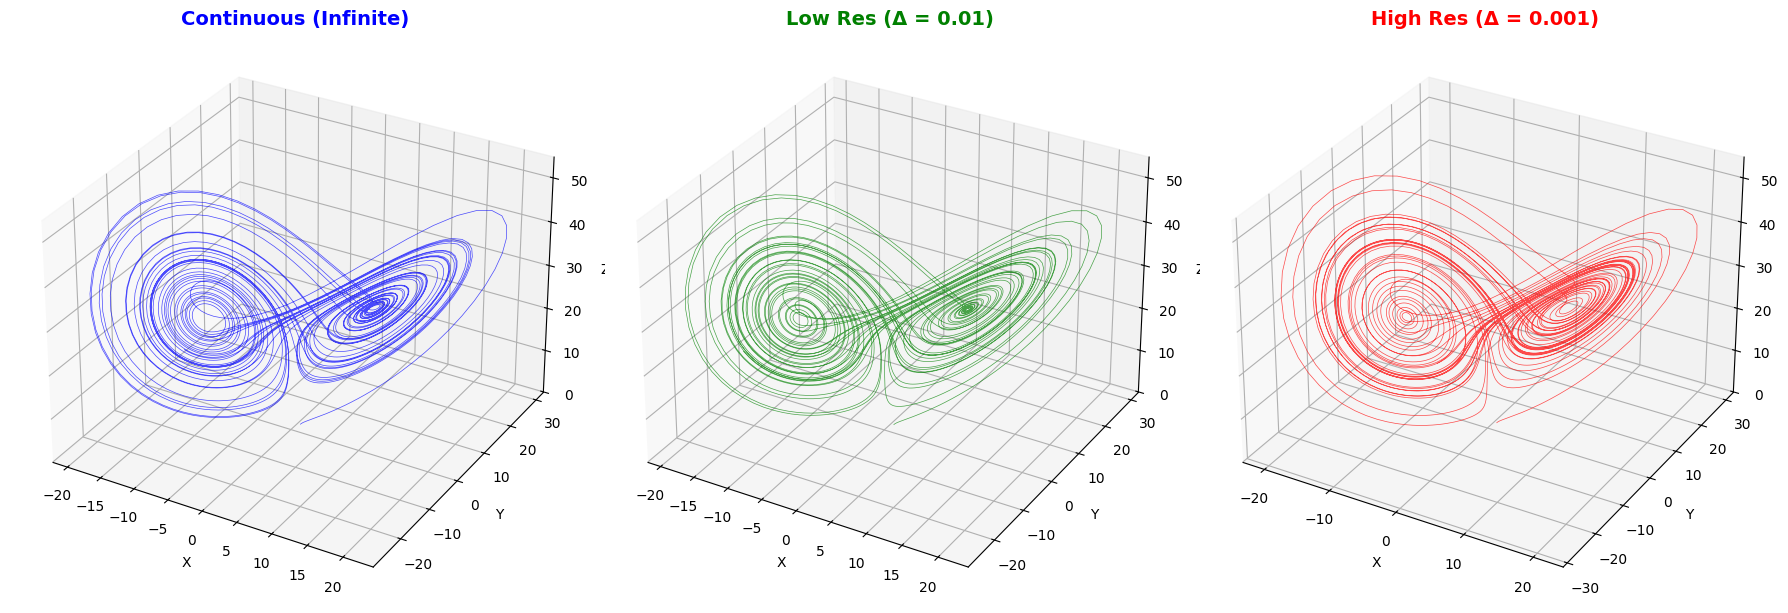


=== Statistics ===
Continuous: x range [-19.24, 21.22]
Δ=0.01: x range [-18.97, 21.21]
Δ=0.001: x range [-20.32, 21.22]


In [3]:
"""
avenue_finitist_lorenz_resolution_scaling.py
====================================================================
APPENDIX SIMULATION: Resolution Scaling of the Finitist Lorenz Attractor
Demonstrating that topology survives quantization as state space increases.

By Néstor E. Ramos

"""
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Lorenz parameters
sigma = 10.0
rho = 28.0
beta = 8.0/3.0
dt = 0.01

def lorenz_derivatives(x, y, z):
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return dx, dy, dz

def simulate_continuous(x0, y0, z0, t_max):
    """Standard continuous Lorenz system."""
    n_steps = int(t_max / dt)
    x, y, z = np.zeros(n_steps), np.zeros(n_steps), np.zeros(n_steps)
    x[0], y[0], z[0] = x0, y0, z0

    for i in range(n_steps - 1):
        dx, dy, dz = lorenz_derivatives(x[i], y[i], z[i])
        x[i+1] = x[i] + dx * dt
        y[i+1] = y[i] + dy * dt
        z[i+1] = z[i] + dz * dt

    return x, y, z

def simulate_discrete(x0, y0, z0, t_max, delta):
    """Discrete Lorenz system with quantization."""
    n_steps = int(t_max / dt)
    x, y, z = np.zeros(n_steps), np.zeros(n_steps), np.zeros(n_steps)
    x[0], y[0], z[0] = x0, y0, z0

    for i in range(n_steps - 1):
        dx, dy, dz = lorenz_derivatives(x[i], y[i], z[i])

        # Apply Euler step
        x_next = x[i] + dx * dt
        y_next = y[i] + dy * dt
        z_next = z[i] + dz * dt

        # Apply quantization (round to nearest multiple of delta)
        x[i+1] = np.round(x_next / delta) * delta
        y[i+1] = np.round(y_next / delta) * delta
        z[i+1] = np.round(z_next / delta) * delta

    return x, y, z

# Initial conditions
x0, y0, z0 = 1.0, 1.0, 1.0
t_max = 50.0

# Simulate with different resolutions
print("Simulating continuous system...")
x_cont, y_cont, z_cont = simulate_continuous(x0, y0, z0, t_max)

print("Simulating with Δ = 0.01 (1000 levels)...")
x_fine, y_fine, z_fine = simulate_discrete(x0, y0, z0, t_max, 0.01)

print("Simulating with Δ = 0.001 (10000 levels)...")
x_very_fine, y_very_fine, z_very_fine = simulate_discrete(x0, y0, z0, t_max, 0.001)

# Plot results
fig = plt.figure(figsize=(18, 6))

# Panel 1: Continuous
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot(x_cont, y_cont, z_cont, 'b-', linewidth=0.5, alpha=0.7)
ax1.set_title('Continuous (Infinite)', fontsize=14, fontweight='bold', color='blue')
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')

# Panel 2: Low Res (Δ = 0.01)
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot(x_fine, y_fine, z_fine, 'g-', linewidth=0.5, alpha=0.7)
ax2.set_title('Low Res (Δ = 0.01)', fontsize=14, fontweight='bold', color='green')
ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')

# Panel 3: High Res (Δ = 0.001)
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot(x_very_fine, y_very_fine, z_very_fine, 'r-', linewidth=0.5, alpha=0.7)
ax3.set_title('High Res (Δ = 0.001)', fontsize=14, fontweight='bold', color='red')
ax3.set_xlabel('X'); ax3.set_ylabel('Y'); ax3.set_zlabel('Z')

plt.tight_layout()
plt.savefig('lorenz_discretization_comparison.png', dpi=150, bbox_inches='tight')
print("Saved: lorenz_discretization_comparison.png")
plt.show()

# Print statistics
print("\n=== Statistics ===")
print(f"Continuous: x range [{x_cont.min():.2f}, {x_cont.max():.2f}]")
print(f"Δ=0.01: x range [{x_fine.min():.2f}, {x_fine.max():.2f}]")
print(f"Δ=0.001: x range [{x_very_fine.min():.2f}, {x_very_fine.max():.2f}]")